In [12]:
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from pathlib import Path

ROOT_DIR = Path().resolve().parent
DATA_DIR = ROOT_DIR / "data" / "processed"
sys.path.append(str(Path().resolve().parent))

from src.config import CONFIG, CAT_CUSTOM

nutri = CONFIG['selected_nutrient']

import gc
gc.collect()

nutriscore_colors = {
        "A": "#008000",
        "B": "#85BB2F",
        "C": "#FFD700",
        "D": "#F78F1E",
        "E": "#E60000"
    }

nutriscore_order = ["A", "B", "C", "D", "E"]

seed = 21
pth = 'C:/Users/lilin/Documents/data science/p1_open_food_facts/data/processed/nutrient_cleaned.parquet'

df = pl.read_parquet(pth)
df = df.with_columns(
    pl.col("nutriscore_grade").str.to_uppercase()
)
df.shape

(906357, 16)

In [14]:
c = 'energy-kcal'
# df.select(pl.col(c).value_counts()).unnest(c).sort(c)
df.filter(
    pl.col(c) == 0
).head(4)

nutriscore_grade,nutriscore_score,product_name,categories_tags,food_groups_tags,energy-kcal,fat,saturated-fat,sugars,proteins,salt,fiber,fruits-vegetables-nuts,tag_0,tag_1,tag_2
str,i32,str,list[str],list[str],f64,f64,f64,f64,f64,f64,f64,f64,str,str,str
"""D""",11,"""Steak haché""","[""en:plant-based-foods-and-beverages"", ""en:plant-based-foods"", … ""en:fresh-meals""]","[""en:composite-foods"", ""en:one-dish-meals""]",0.0,8.2,3.2,1.9,18.0,1.5,3.9,0.0,"""processed_food""",null,null
"""A""",0,"""Beterraves rouges""","[""en:plant-based-foods-and-beverages"", ""en:plant-based-foods"", … ""en:salads""]","[""en:composite-foods"", ""en:one-dish-meals""]",0.0,1.0,1.0,4.6,1.0,0.1,2.1,78.800003,"""processed_food""",null,null
"""A""",0,"""Greenwise organic diced bartle…","[""en:plant-based-foods-and-beverages"", ""en:plant-based-foods"", … ""en:canned-fruits""]","[""en:fruits-and-vegetables"", ""en:fruits""]",0.0,0.0,0.0,9.734513,0.0,0.0,1.8,0.0,"""fruits_vege_legumes""",null,null
"""E""",24,"""Mon Gâteau Nature""","[""en:snacks"", ""en:desserts"", … ""en:cakes""]","[""en:sugary-snacks"", ""en:biscuits-and-cakes""]",0.0,9.6,9.6,19.0,4.5,1.1,0.0,0.0,"""sweet_desserts""",null,null


### Distribution

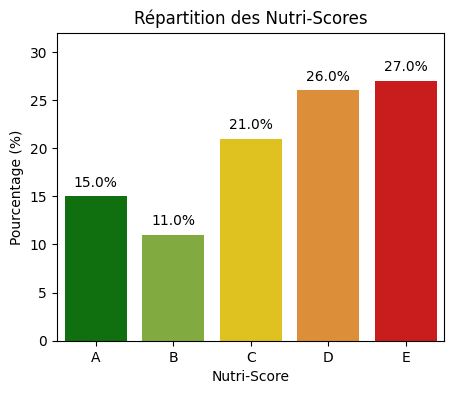

In [ ]:
# NUTRI SCORE dans les données % par classe
df_plot = df.to_pandas()
val_count = round(df_plot["nutriscore_grade"].value_counts(normalize=True) * 100)  # Pourcentage
val_count = val_count.reindex(nutriscore_order)  # Assure l'ordre

df_plot = val_count.reset_index()
df_plot.columns = ["nutriscore_grade", "percentage"]
df_plot['nutriscore_grade'] = df_plot['nutriscore_grade'].str.upper()

plt.figure(figsize=(5, 4))
sns.barplot(data=df_plot, 
            x="nutriscore_grade", 
            y="percentage",
            hue="nutriscore_grade",
            palette=[nutriscore_colors[grade] for grade in df_plot["nutriscore_grade"]]
            )

for i, pct in enumerate(df_plot["percentage"]):
    plt.text(i, pct + 1, f"{pct:.1f}%", ha="center")

plt.title("Répartition des Nutri-Scores")
plt.ylabel("Pourcentage (%)")
plt.xlabel("Nutri-Score")
plt.ylim(0, df_plot["percentage"].max() + 5)
plt.show()

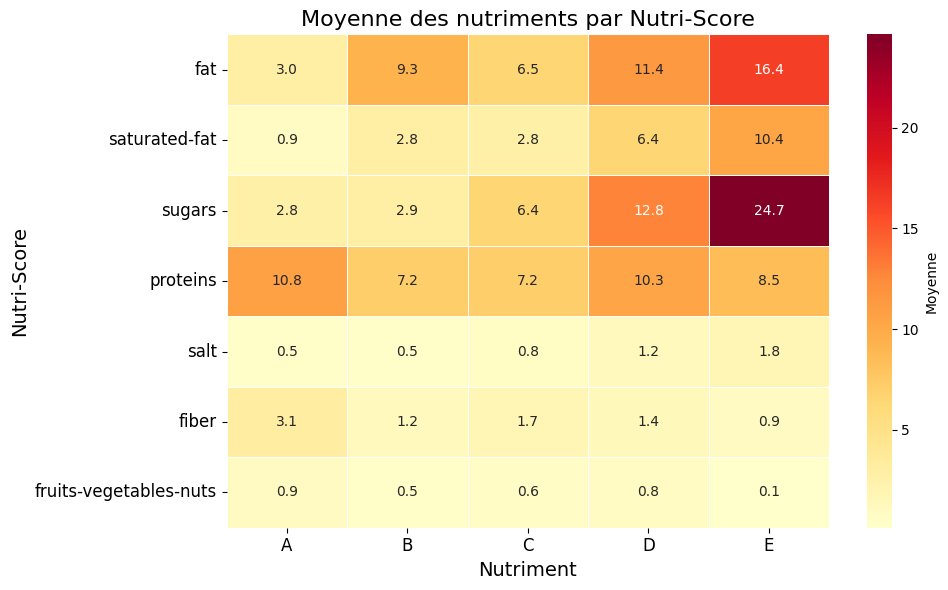

In [16]:
# Moyenne des nutriments par nutriscore
df_heatmap = (
    df
    .group_by("nutriscore_grade")
    .agg([pl.mean(col).alias(col) for col in nutri if col != 'energy-kcal'])
    .sort("nutriscore_grade")
)

df_heatmap_pd = df_heatmap.to_pandas().set_index("nutriscore_grade")
df_heatmap_pd = df_heatmap_pd.loc[nutriscore_order]

plt.figure(figsize=(10, 6))

sns.heatmap(
    df_heatmap_pd.T,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Moyenne"}
)

plt.title("Moyenne des nutriments par Nutri-Score", fontsize=16)
plt.xlabel("Nutriment", fontsize=14)
plt.ylabel("Nutri-Score", fontsize=14)
plt.xticks( fontsize=12)  # rotation=45
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


c:\Users\lilin\AppData\Local\pypoetry\Cache\virtualenvs\foodapp-WvfPqYev-py3.13\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


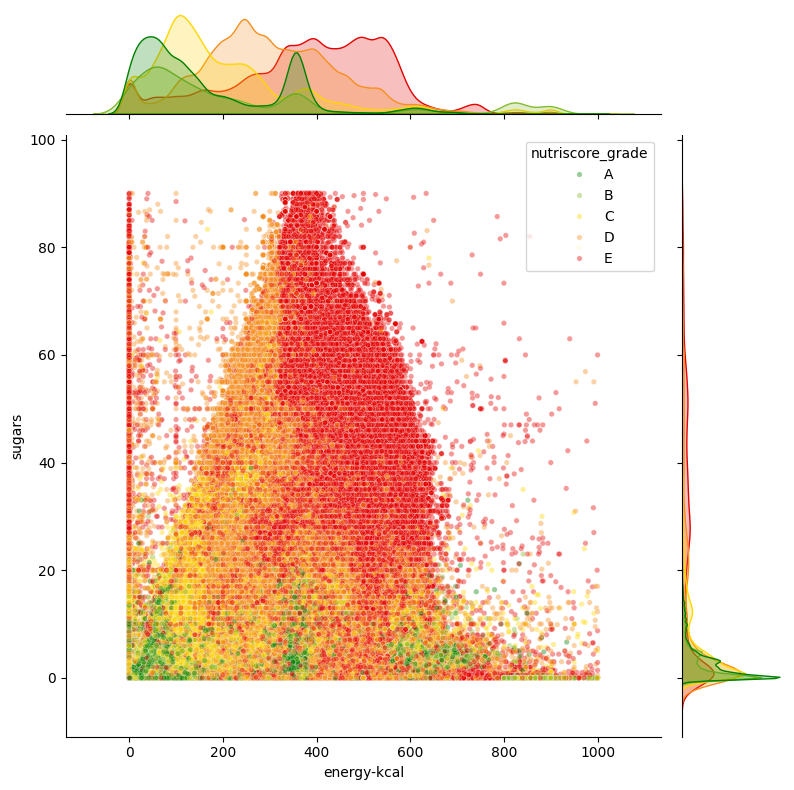

In [19]:
sns.jointplot(
    data=df.to_pandas(), 
    x="energy-kcal",
    y="sugars",
    kind="scatter",  
    hue="nutriscore_grade",
    hue_order=["A", "B", "C", "D", "E"],
    palette=nutriscore_colors,
    height=8,
    s=15,
    alpha=0.4
    )

plt.show()

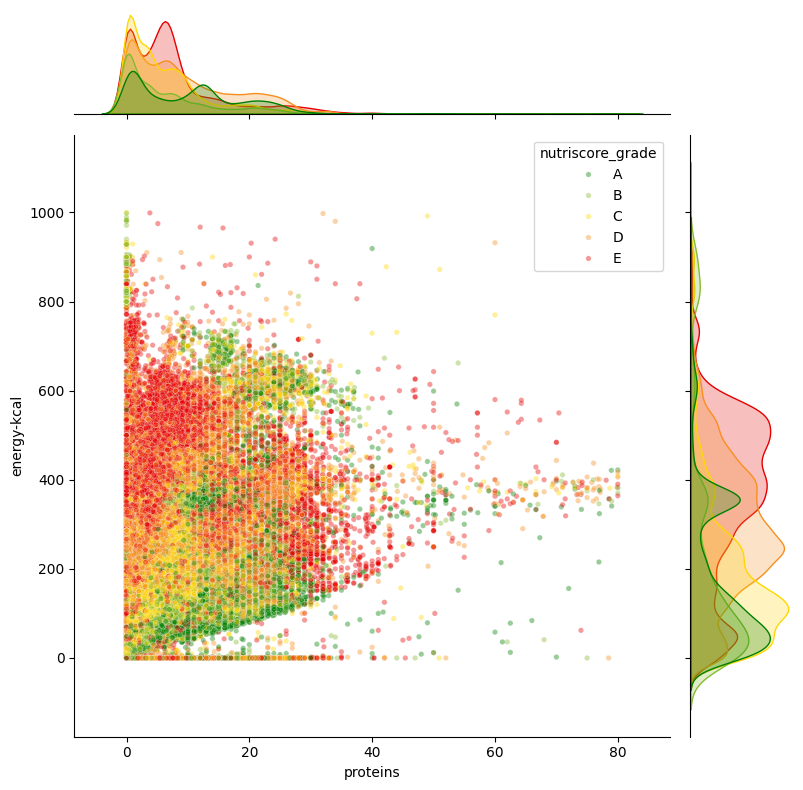

In [ ]:
sns.jointplot(
    data=df.to_pandas(), 
    x="energy-kcal",
    y="proteins", 
    kind="scatter",  
    hue="nutriscore_grade",
    hue_order=["A", "B", "C", "D", "E"],
    palette=nutriscore_colors,
    height=8,
    s=15,
    alpha=0.4
    )

plt.show()

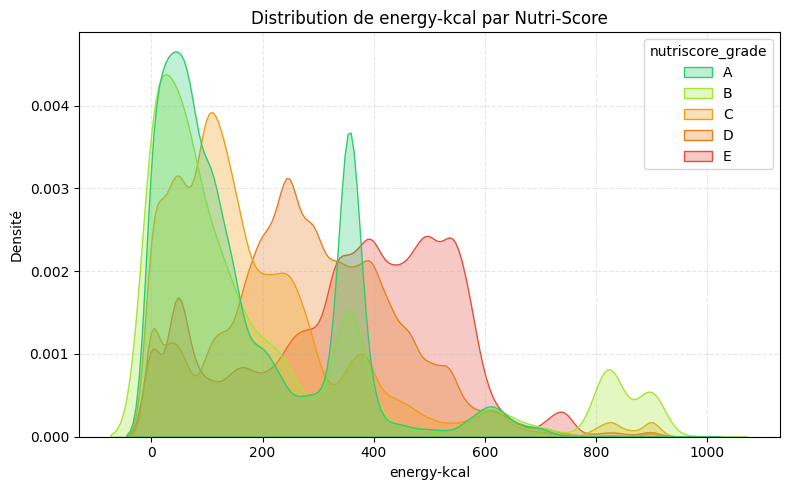

In [ ]:
c = "energy-kcal"

plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=df,
    x=c,
    hue="nutriscore_grade",
    hue_order=nutriscore_order,
    palette=nutriscore_colors,
    common_norm=False,  # normalise chaque courbe indépendamment
    fill=True,
    alpha=0.3
)
plt.title(f"Distribution de {c} par Nutri-Score")
plt.xlabel(c)
plt.ylabel("Densité")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

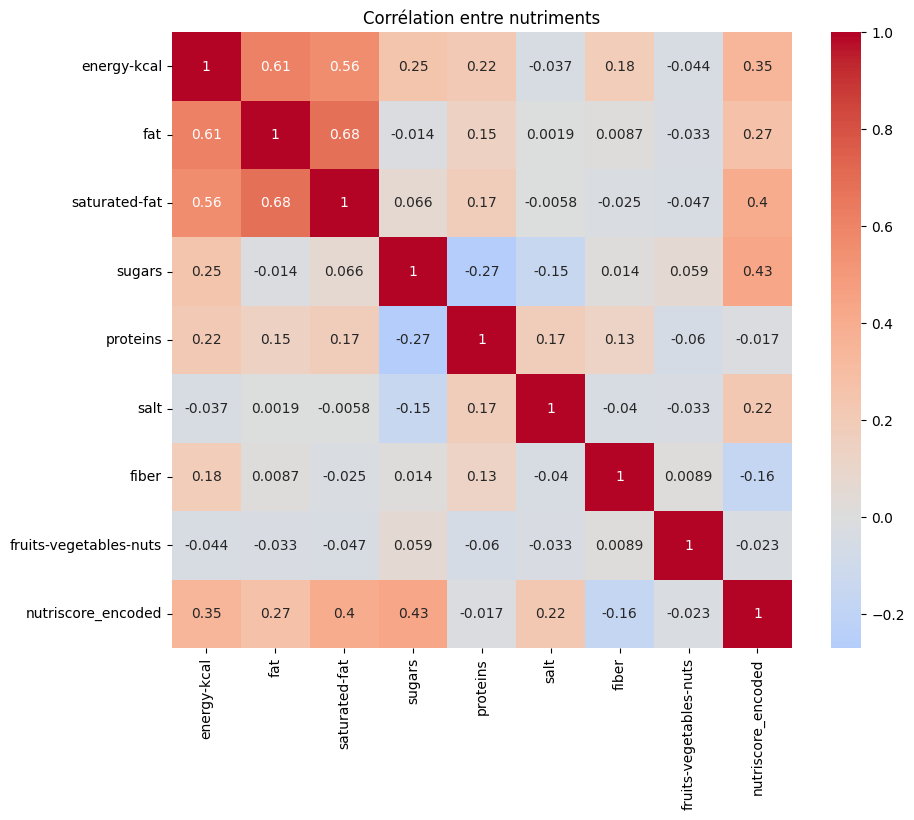

In [ ]:
df_sample = df_sample.with_columns(
    pl.when(pl.col("nutriscore_grade") == "a").then(0)
    .when(pl.col("nutriscore_grade") == "b").then(1)
    .when(pl.col("nutriscore_grade") == "c").then(2)
    .when(pl.col("nutriscore_grade") == "d").then(3)
    .when(pl.col("nutriscore_grade") == "e").then(4)
    .otherwise(None)
    .alias("nutriscore_encoded")
)
df_sample = df_sample.drop(['nutriscore_score', 'product_name', 'nutriscore_grade'])

corr = df_sample.to_pandas().corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Corrélation entre nutriments")
plt.show()